# House Price Prediction Linear Regression

**Neurofive ML Track-Week 2: House Price Prediction with Linear Regression**

Goal: predict `SalePrice` using a small, hand-picked set of features and a Linear Regression model the regression counterpart to the Titanic classification task.

Dataset: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) (Kaggle)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()

train shape: (1460, 81)
test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 3a. Summary statistics

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 3b. Missing values across the full dataset

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### 3c. Categorical vs. numerical columns

In [7]:
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):", numerical_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

Numerical columns (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',

### 3d. EDA takeaways

- 1,460 training rows, 81 columns (80 features + `SalePrice`).
- A handful of columns are almost entirely missing `PoolQC`, `MiscFeature`, `Alley`, `Fence` because most houses simply don't have a pool, alley access, or fence (per `data_description.txt`, `NA` there means "None", not "unknown"). `FireplaceQu`, `LotFrontage`, and the garage/basement columns have moderate missingness for the same reason: the feature genuinely doesn't apply to that house.
- `SalePrice` (the target) itself is right-skewed most homes cluster at moderate prices with a long tail of expensive outliers, confirmed visually below.
- The 5 features chosen for modeling (`OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `YearBuilt`) have **zero missing values**, so no imputation is needed for the regression itself but the broader dataset clearly needs a real missing-value strategy before using more columns.


## 4. Clean & Visualize

**Missing-value handling (for columns relevant to context, even though the 5 modeling features are already complete):**

- Columns like `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, `GarageType` → fill with `"None"` using `fillna()`, since `NA` here means the feature is genuinely absent, not unrecorded.
- `LotFrontage` → fill with the median per `Neighborhood`, since frontage tends to cluster by neighborhood layout.
- The 5 features actually used in the model (`OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `YearBuilt`) are dropped straight into `dropna()`-safe territory confirmed complete in the EDA step above, so no fillna/dropna was needed on them specifically.


In [8]:
train_clean = train.copy()

none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType",
             "GarageFinish", "GarageQual", "GarageCond", "BsmtQual", "BsmtCond",
             "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for col in none_cols:
    if col in train_clean.columns:
        train_clean[col] = train_clean[col].fillna("None")

train_clean["LotFrontage"] = train_clean.groupby("Neighborhood")["LotFrontage"].transform(
    lambda s: s.fillna(s.median())
)

print("Remaining missing values (top 10):")
print(train_clean.isnull().sum().sort_values(ascending=False).head(10))

Remaining missing values (top 10):
MasVnrType     872
GarageYrBlt     81
MasVnrArea       8
Electrical       1
LotArea          0
MSSubClass       0
MSZoning         0
LotFrontage      0
LandContour      0
Utilities        0
dtype: int64


### 4a. Outlier detection: boxplot on `GrLivArea`

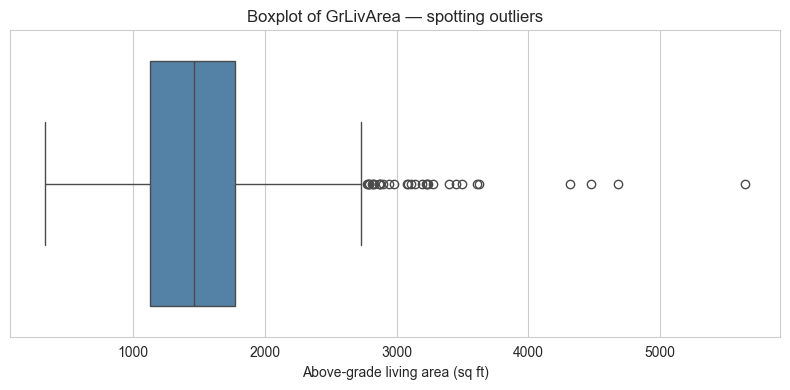

IQR upper bound: 2748 sq ft
Number of GrLivArea outliers: 31


In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_clean["GrLivArea"], color="steelblue")
plt.title("Boxplot of GrLivArea — spotting outliers")
plt.xlabel("Above-grade living area (sq ft)")
plt.tight_layout()
plt.show()

q1, q3 = train_clean["GrLivArea"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (train_clean["GrLivArea"] > upper_bound).sum()
print(f"IQR upper bound: {upper_bound:.0f} sq ft")
print(f"Number of GrLivArea outliers: {n_outliers}")

### 4b. Histogram: distribution of `SalePrice`

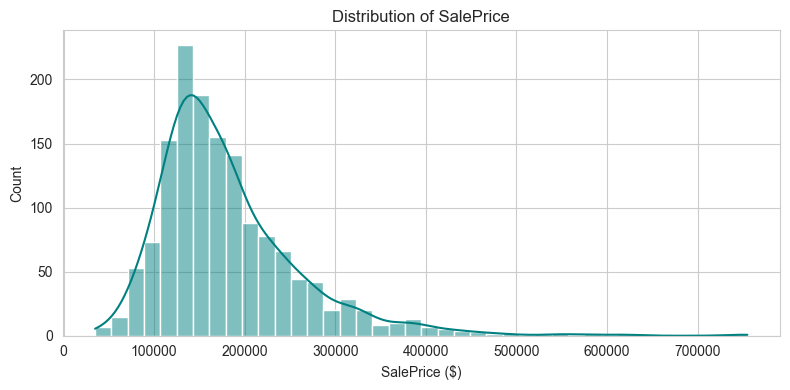

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(train_clean["SalePrice"], bins=40, kde=True, color="teal")
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 4c. Bar chart: average `SalePrice` by `OverallQual`

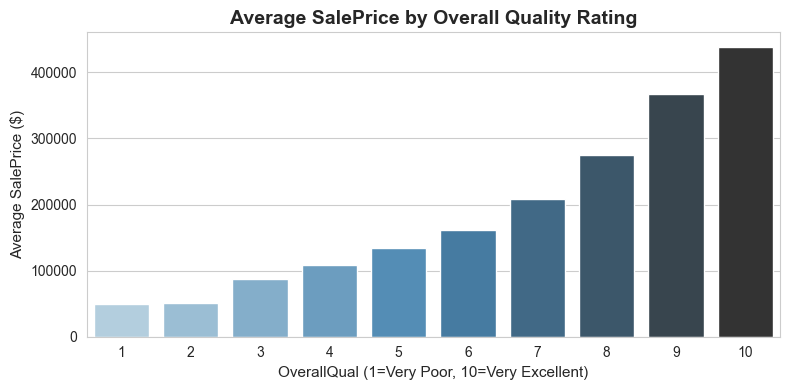

In [12]:
plt.figure(figsize=(8, 4))
avg_price_by_qual = train_clean.groupby("OverallQual")["SalePrice"].mean()
sns.barplot(x=avg_price_by_qual.index, y=avg_price_by_qual.values, 
            hue=avg_price_by_qual.index, palette="Blues_d", legend=False)
plt.title("Average SalePrice by Overall Quality Rating", fontsize=14, fontweight='bold')
plt.xlabel("OverallQual (1=Very Poor, 10=Very Excellent)", fontsize=11)
plt.ylabel("Average SalePrice ($)", fontsize=11)
plt.tight_layout()
plt.show()

### 4d. Correlation heatmap

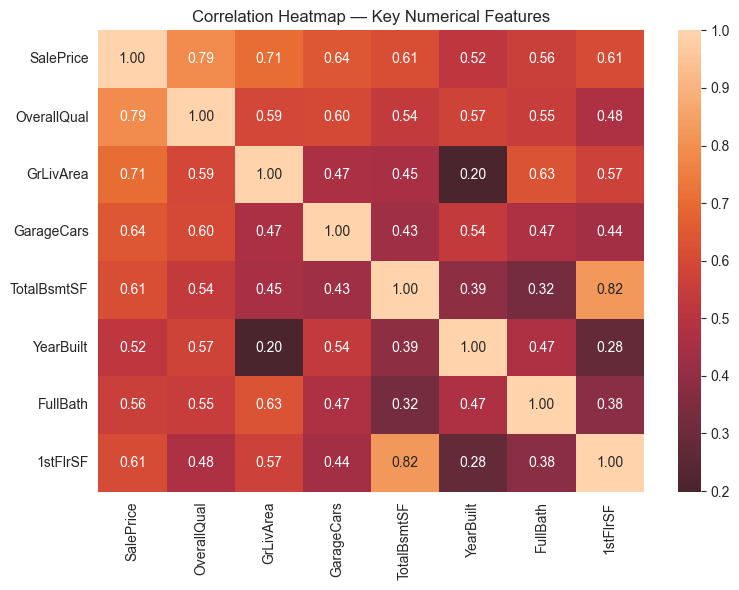

In [14]:
corr_cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt", "FullBath", "1stFlrSF"]
corr = train_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="icefire", center=0)
plt.title("Correlation Heatmap — Key Numerical Features")
plt.tight_layout()
plt.show()

### 4e. What the visuals show

- `GrLivArea` has a real cluster of large-house outliers above the IQR upper bound a handful of very large homes.
- `SalePrice` is clearly right-skewed: most homes sell in a moderate range, with a long tail of expensive outliers this is exactly the pattern that motivates log-transforming price in more advanced modeling.
- Average price rises sharply and fairly consistently with `OverallQual` quality rating is a strong, almost monotonic price driver.
- The heatmap confirms `OverallQual` and `GrLivArea` have the strongest correlation with `SalePrice` among the numerical features checked, which is consistent with why they were picked for the regression model below.


## 5. Feature selection

Picking 5 features I'd expect to affect price most, based on the data dictionary (`data_description.txt`) and domain intuition:

- **`OverallQual:`** overall material/finish quality (1–10 rating), a direct quality signal buyers pay for
- **`GrLivArea:`** above-grade living area in square feet, bigger livable space, higher price
- **`GarageCars:`** garage capacity, proxy for both space and amenity value
- **`TotalBsmtSF:`** total basement square footage, extra usable space
- **`YearBuilt:`** original construction year, newer homes typically command higher prices


In [15]:
features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]
target = "SalePrice"

model_df = train[features + [target]].copy()
print("Missing values in selected features:\n", model_df.isnull().sum())
model_df.describe()

Missing values in selected features:
 OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
YearBuilt      0
SalePrice      0
dtype: int64


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1971.267808,180921.195890
std,1.382997,525.480383,0.747315,438.705324,30.202904,79442.502883
min,1.000000,334.000000,0.000000,0.000000,1872.000000,34900.000000
25%,5.000000,1129.500000,1.000000,795.750000,1954.000000,129975.000000
50%,6.000000,1464.000000,2.000000,991.500000,1973.000000,163000.000000
75%,7.000000,1776.750000,2.000000,1298.250000,2000.000000,214000.000000
max,10.000000,5642.000000,4.000000,6110.000000,2010.000000,755000.000000


## 6. Train/test split

In [16]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1168, 5)
X_test shape: (292, 5)


## 7. Train the Linear Regression model

In [17]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

coef_table = pd.DataFrame({"feature": features, "coefficient": lin_reg.coef_})
print("Intercept:", lin_reg.intercept_)
coef_table

Intercept: -694533.3581039725


,feature,coefficient
0,OverallQual,20392.513001
1,GrLivArea,48.809801
2,GarageCars,15144.237204
3,TotalBsmtSF,25.365319
4,YearBuilt,315.923350


## 8. Evaluate: RMSE and R²

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R\u00b2 score: {r2:.4f}")

RMSE: 39,763.30
R² score: 0.7939


## 9. Predicted vs. Actual: scatter plot

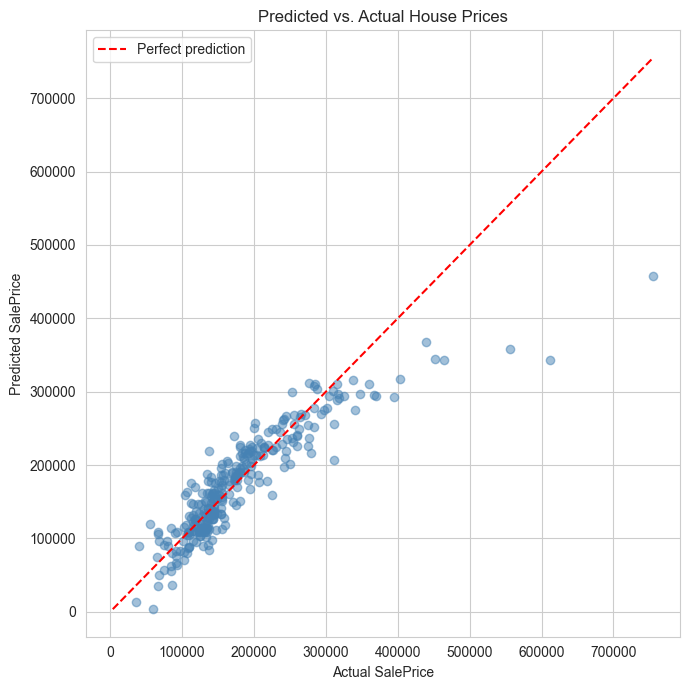

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs. Actual House Prices")
plt.legend()
plt.tight_layout()
plt.show()

## 10. What does the R² score mean? (plain English)

R² tells us how much of the variation in house prices our model manages to explain, on a scale where 1.0 would be a perfect prediction and 0 would mean the model is no better than just guessing the average price every time. Our model scored **R² ≈ 0.79**, meaning it explains about 79% of the differences in price between houses, using just five features like quality rating, living area, garage size, basement size, and age. That's a solid result for a simple model, though the remaining gap (the part R² doesn't explain) is down to things we didn't include, like neighborhood, exact location, or renovation history. In short: the model is a useful first estimate of price, but not the final word.


## 11. Summary

- **Model:** Linear Regression (`scikit-learn`), trained on 5 features: `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `YearBuilt`
- **Split:** 80/20 train/test
- **Metrics:** see RMSE and R² printed above
- **Next steps:** try adding more features (e.g. `Neighborhood`, `LotArea`), log-transforming `SalePrice` to handle its right skew, and comparing against regularized models (Ridge/Lasso) or tree-based regressors.
